# SiN-to-AlOx integrated waveguide vertical coupler

This notebook models optical coupling between a silicon nitride (SiN) waveguide and an alumina (Al₂O₃ / AlOx) waveguide stack relevant to monolithically integrated Er-doped Al₂O₃ amplifiers on a silicon photonics platform. The simulated device element is an interlayer taper coupler: a SiN waveguide transitions from a wide section to a narrow tip while an AlOx waveguide transitions from a narrow tip to a wider section above it, separated by a spacer and including a SiO₂ gap layer within the SiN stack, with the goal of transferring the guided mode efficiently between layers near the C-band. The design is based on `C. E. Osornio-Martinez, D. B. Bonneville, I. Hegeman, M. Dijkstra, Q. Segondat, R. Dekker, and S. M. García-Blanco, "Monolithically integrated erbium-doped polycrystalline Al2O3 waveguide amplifier on silicon photonics platform," Opt. Express 33, 23491-23502 (2025).` [DOI: 10.1364/OE.562888](https://doi.org/10.1364/OE.562888).

<img src="img/vertical_coupler.png" alt="shematic of the coupler" width="500" />

The workflow first runs a set of mode-solver simulations to visualize modal fields and quantify mode overlap versus horizontal shift of the waveguide at multiple wavelengths, identifying alignment sensitivity. Then, it sets up an eigenmode expansion (EME) model and performs a length sweep of the taper region to study how transmission/coupling behavior evolves with taper length. Finally, an FDTD simulation is performed to verify the device performance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web

## Simulation Setup

We start with the basic simulation setup by defining the wavelength range of interest, materials, and geometries of the vertical coupler. See the referenced paper for details of the design and layer stack. 

In [2]:
# Define central wavelength and corresponding frequency
lda0 = 1.55
freq0 = td.C_0 / lda0

# Define wavelength range and convert to frequencies
ldas = np.linspace(1.48, 1.62, 3)
freqs = td.C_0 / ldas

# Source bandwidth
fwidth = 0.5 * (np.max(freqs) - np.min(freqs))

We will create a lossless AlOx medium using a constant refractive index, and we will load predefined SiN and oxide materials from the [material library](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/material_library.html).

In [3]:
n_AlOx = 1.724  # Refractive index for AlOx

AlOx = td.Medium.from_nk(
    n=n_AlOx, k=0, freq=freq0
)  # Create AlOx medium using constant n and zero extinction (lossless)

SiN = td.material_library["Si3N4"][
    "Luke2015Sellmeier"
]  # Silicon nitride material model from library

SiO2 = td.material_library["SiO2"][
    "Palik_LowLoss"
]  # Lossless silicon dioxide model from Palik in material library

Define geometric parameters for a multilayer SiN stack and an AlOx layer.

In [4]:
w_SiN_tip = 0.3  # SiN tip width
w_SiN_wg = 1.2  # SiN waveguide width

t_SiN_top = 0.175  # SiN top layer thickness
t_SiN_gap = 0.1  # Gap thickness between SiN layers
t_SiN_bottom = 0.075  # SiN bottom layer thickness
t_SiN = t_SiN_bottom + t_SiN_gap + t_SiN_top  # Total SiN stack thickness

t_spacer = 0.35  # Spacer layer thickness

w_AlOx_tip = 0.2  # AlOx tip width
w_AlOx_wg = 1.75  # AlOx waveguide width
t_AlOx = 0.75  # AlOx layer thickness

sidewall_angle = np.deg2rad(10)  # Sidewall angle in radians (converted from degrees)
inf_eff = 1e4  # Effective infinity

We design the vertical coupler by optimizing the taper length and the horizontal offset between the AlOx and SiN waveguides. To support this, we define a `create_structures` function that generates the coupler geometry for a given taper length and horizontal shift.

In [5]:
def create_structures(l_taper, y_shift):
    """Create simulation structures for a coupled SiN–AlOx taper with an SiO2 gap.

    Args:
        l_taper: Taper length used for both SiN and AlOx polygon definitions.
        y_shift: Vertical (y-axis) offset applied to the AlOx waveguide geometry.

    Returns:
        List of `td.Structure` objects in the order: [AlOx waveguide, SiN waveguide, SiO2 gap].
    """
    # Define SiN taper polygon (x, y) vertices, centered about y = 0
    vertices = [
        (-inf_eff, -w_SiN_wg / 2),
        (-inf_eff, w_SiN_wg / 2),
        (0, w_SiN_wg / 2),
        (l_taper, w_SiN_tip / 2),
        (l_taper, -w_SiN_tip / 2),
        (0, -w_SiN_wg / 2),
    ]

    # Create SiN waveguide geometry as an extruded polygon in z
    SiN_wg_geometry = td.PolySlab(
        vertices=vertices,
        axis=2,
        slab_bounds=(0, t_SiN),
        sidewall_angle=sidewall_angle,
        reference_plane="top",
    )

    # Wrap SiN geometry into a structure with the SiN material
    wg_SiN = td.Structure(geometry=SiN_wg_geometry, medium=SiN)

    # Create SiO2 gap layer as a box spanning the full simulation x/y extents
    SiO2_gap = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-inf_eff, -inf_eff, t_SiN_bottom),  # bottom of gap in z
            rmax=(inf_eff, inf_eff, t_SiN_bottom + t_SiN_gap),  # top of gap in z
        ),
        medium=SiO2,
    )

    # Define AlOx taper polygon vertices with vertical offset (y_shift)
    vertices = [
        (0, -w_AlOx_tip / 2 + y_shift),
        (0, w_AlOx_tip / 2 + y_shift),
        (l_taper, w_AlOx_wg / 2 + y_shift),
        (inf_eff, w_AlOx_wg / 2 + y_shift),
        (inf_eff, -w_AlOx_wg / 2 + y_shift),
        (l_taper, -w_AlOx_wg / 2 + y_shift),
    ]

    # Create AlOx waveguide geometry (positioned above SiN with spacer and AlOx thickness)
    AlOx_wg_geometry = td.PolySlab(
        vertices=vertices,
        axis=2,
        slab_bounds=(t_SiN + t_spacer, t_SiN + t_spacer + t_AlOx),
        sidewall_angle=sidewall_angle,
        reference_plane="top",
    )

    # Wrap AlOx geometry into a structure with the AlOx material
    wg_AlOx = td.Structure(geometry=AlOx_wg_geometry, medium=AlOx)

    # Return structures in the intended stacking/usage order
    return [wg_AlOx, wg_SiN, SiO2_gap]

## Mode Overlap Calculation for Misalignment Analysis

We first optimize the horizontal offset by maximizing the mode-overlap integral. This requires running mode-solver simulations across a range of horizontal offsets.

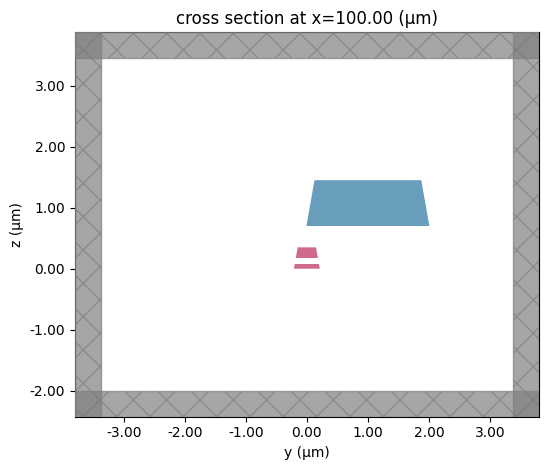

In [6]:
# Buffer spacing
buffer_x = 5
buffer_y = 2.5
buffer_z = 2

l_taper_0 = 100  # Base taper length used to define the simulation domain

# Define a simulation domain box
sim_box = td.Box.from_bounds(
    rmin=(-buffer_x, -w_AlOx_wg / 2 - buffer_y, -buffer_z),
    rmax=(
        l_taper_0 + buffer_x,
        w_AlOx_wg / 2 + buffer_y,
        t_SiN + t_spacer + t_AlOx + buffer_z,
    ),
)

# Finite difference grid specification
grid_spec = td.GridSpec.auto(min_steps_per_wvl=30, wavelength=lda0)

# Mode solving specification
mode_spec = td.ModeSpec(precision="double", target_neff=2, num_modes=1)

# Set up a mode simulation
mode_sim_c1 = td.ModeSimulation(
    center=sim_box.center,
    size=sim_box.size,
    freqs=freqs,
    grid_spec=grid_spec,
    structures=create_structures(l_taper_0, 1),
    plane=td.Box(center=(-buffer_x / 2, 0, 0), size=(0, td.inf, td.inf)),
    mode_spec=mode_spec,
    medium=SiO2,
)

# Plot the mode simulation
mode_sim_c1.plot(x=l_taper_0)
plt.show()

In [7]:
mode_sim_c2 = mode_sim_c1.updated_copy(
    plane=td.Box(
        center=(0, 0, 0), size=(0, td.inf, td.inf)
    ),  # Update the mode plane to the y-z plane at x=0
)

y_shift_list = np.linspace(0, 1, 11)  # Sweep y-shift values from 0 to 1 with 11 samples
mode_sims = {
    f"y_shift={y_shift:.2f}": mode_sim_c2.updated_copy(
        structures=create_structures(l_taper_0, y_shift)
    )
    for y_shift in y_shift_list  # Build a dict of simulations keyed by formatted y-shift label
}
mode_sims["c1"] = mode_sim_c1

batch = web.Batch(simulations=mode_sims)  # Create a batch job containing all simulations
batch_results = batch.run(path_dir="data")  # Run the batch

y_shift=0.00    → success ━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:09
y_shift=0.10    → success ━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:09
y_shift=0.20    → success ━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:09
y_shift=0.30    → success ━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:09
y_shift=0.40    → success ━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:09
y_shift=0.50    → success ━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:09
y_shift=0.60    → success ━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:09
y_shift=0.70    → success ━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:09
y_shift=0.80    → success ━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:08
y_shift=0.90    → success ━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:08
y_shift=1.00    → success ━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:08
c1              → success ━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:08

23:13:36 Eastern Standard Time Batch complete.

Plot the mode profiles.

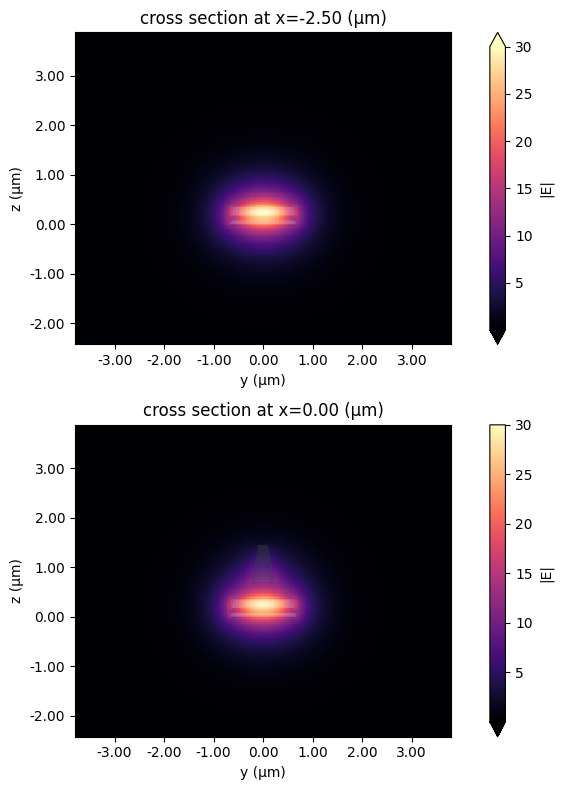

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(8, 8), tight_layout=True)

batch_results["c1"].plot_field("E", "abs", f=freq0, vmax=30, ax=ax[0])

batch_results[f"y_shift={y_shift_list[0]:.2f}"].plot_field(
    "E",
    "abs",
    f=freq0,
    vmax=30,
    ax=ax[1],
)

plt.show()

The mode overlap integral can be calculated by the `outer_dot` method. We plot the overlap as a function of horizontal shift and find that 1 µm shift will significantly reduce the mode mismatch compared to a smaller shift. For the rest of the design, we will use 1 µm shift.

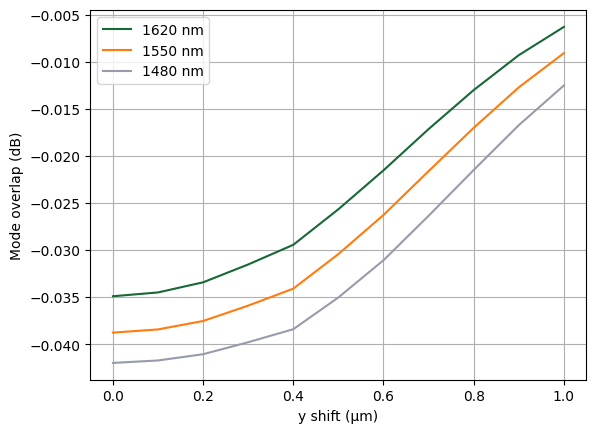

In [9]:
overlap = np.array(
    [
        # Compute the mode overlap between the shifted case and the reference ("c1") for each y-shift
        batch_results[f"y_shift={y_shift:.2f}"]
        .modes.outer_dot(
            batch_results["c1"].modes
        )  # Outer product of modes to get overlaps between mode sets
        .values.squeeze()
        for y_shift in y_shift_list
    ]
)

# Plot overlap magnitude (in dB) versus y-shift for each wavelength index
plt.plot(y_shift_list, 20 * np.log10(np.abs(overlap[:, 0])), label="1620 nm")
plt.plot(y_shift_list, 20 * np.log10(np.abs(overlap[:, 1])), label="1550 nm")
plt.plot(y_shift_list, 20 * np.log10(np.abs(overlap[:, 2])), label="1480 nm")


plt.xlabel("y shift (μm)")
plt.ylabel("Mode overlap (dB)")
plt.grid()
plt.legend()
plt.show()

## EME Simulation

Next, we need to optimize the coupler length to maximize coupling efficiency. EME enables this to be done very efficiently. We will sweep the taper length from 100 µm to 1 mm.

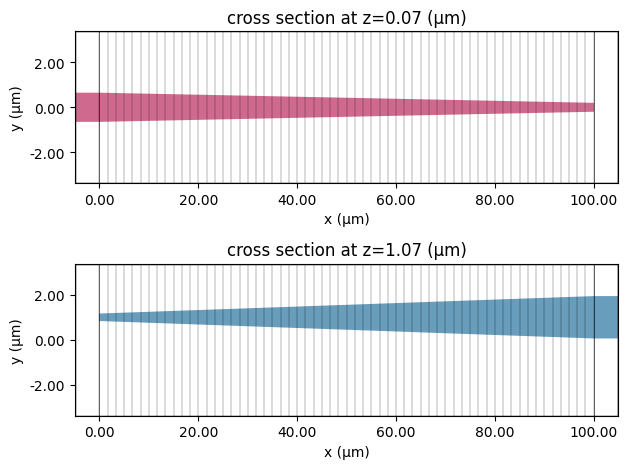

In [10]:
grid_1 = td.EMEUniformGrid(
    num_cells=1,  # Single EME cell for uniform sections
    mode_spec=td.EMEModeSpec(num_modes=10, precision="double"),
)
grid_2 = td.EMEUniformGrid(
    num_cells=60,  # Finer discretization for the taper region
    mode_spec=td.EMEModeSpec(num_modes=10, precision="double"),
)

l_taper_list = np.linspace(100, 1000, 100)  # Taper lengths to sweep

eme_grid = td.EMECompositeGrid(
    subgrids=[grid_1, grid_2, grid_1],  # Left uniform -> taper -> right uniform
    subgrid_boundaries=[
        0,
        l_taper_0,
    ],  # Boundary location(s) between subgrids (taper starts at x=0, ends at x=l_taper_0)
)

y_shift_opt = 1  # Optimal vertical shift

eme_sim = td.EMESimulation(
    center=sim_box.center,
    size=sim_box.size,
    structures=create_structures(l_taper_0, y_shift_opt),
    grid_spec=grid_spec,
    medium=SiO2,
    eme_grid_spec=eme_grid,
    freqs=freqs,
    axis=0,
    sweep_spec=td.EMELengthSweep(
        scale_factors=l_taper_list / l_taper_0
    ),  # Sweep taper length via scale factors
    store_port_modes=False,
)

fig, ax = plt.subplots(2, 1, tight_layout=True)
eme_sim.plot(z=t_SiN_bottom, ax=ax[0])
ax[0].set_aspect("auto")
eme_sim.plot(z=t_SiN_top + t_SiN_bottom + t_SiN_gap + t_spacer + t_AlOx / 2, ax=ax[1])
ax[1].set_aspect("auto")
plt.show()

Plot cross-sections of the coupler at multiple $x$ positions.

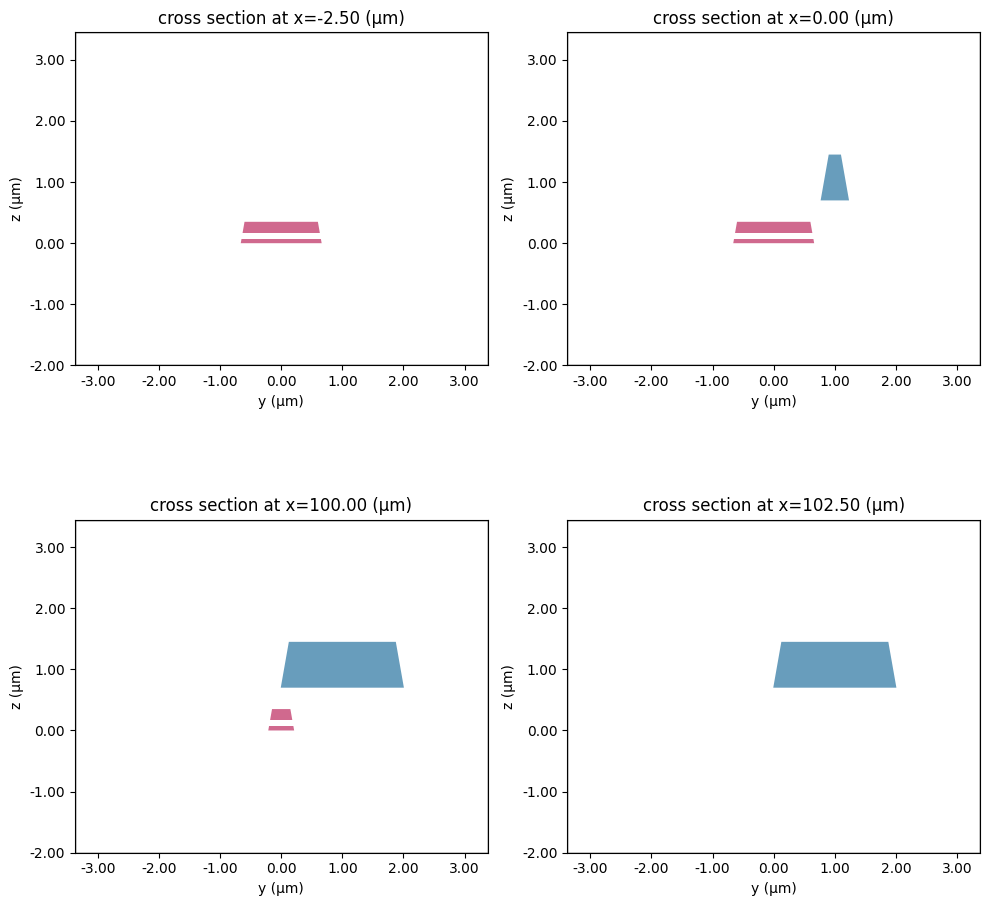

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10), tight_layout=True)

eme_sim.plot(x=-buffer_x / 2, ax=ax[0, 0])
eme_sim.plot(x=0, ax=ax[0, 1])
eme_sim.plot(x=l_taper_0, ax=ax[1, 0])
eme_sim.plot(x=l_taper_0 + buffer_x / 2, ax=ax[1, 1])

plt.show()

Run the EME simulation.

In [12]:
eme_sim_data = web.run(eme_sim, task_name="EME")

↓ simulation_data.hdf5.gz ━━━━━━━━━━━━━ 100.0% • 1.9/1.9 MB • 6.2 MB/s • 0:00:00

23:14:01 Eastern Standard Time Loading simulation from simulation_data.hdf5

23:14:02 Eastern Standard Time WARNING: Warning messages were found in the      
                               solver log. For more information, check          
                               'SimulationData.log' or use                      
                               'web.download_log(task_id)'.                     

Plot the coupling efficiency as a function of taper length. The coupling efficiency saturates at approximately 400 µm. Increasing the taper length beyond 400 µm provides no additional benefit.

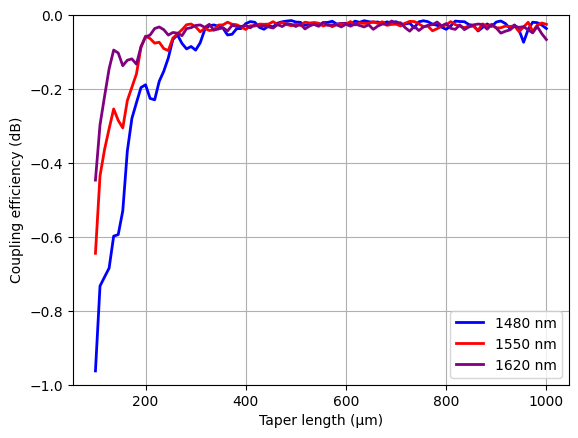

In [13]:
T_0 = (
    eme_sim_data.smatrix.S21.isel(mode_index_in=0, mode_index_out=0, f=0).abs
) ** 2  # Power transmission at f index 0 (1480 nm)
T_1 = (
    eme_sim_data.smatrix.S21.isel(mode_index_in=0, mode_index_out=0, f=1).abs
) ** 2  # Power transmission at f index 1 (1550 nm)
T_2 = (
    eme_sim_data.smatrix.S21.isel(mode_index_in=0, mode_index_out=0, f=2).abs
) ** 2  # Power transmission at f index 2 (1620 nm)

plt.plot(l_taper_list, 10 * np.log10(T_0), c="blue", linewidth=2, label="1480 nm")
plt.plot(l_taper_list, 10 * np.log10(T_1), c="red", linewidth=2, label="1550 nm")
plt.plot(l_taper_list, 10 * np.log10(T_2), c="purple", linewidth=2, label="1620 nm")
plt.legend()
plt.xlabel("Taper length (µm)")
plt.ylabel("Coupling efficiency (dB)")
plt.ylim(-1, 0)
plt.grid()
plt.show()

## FDTD Simulation

Finally, we will run an FDTD simulation using the optimal taper length to verify the design’s performance.

In [14]:
l_taper_opt = 400  # Length of the optimized taper section (in simulation length units)

mode_source = td.ModeSource(
    center=(-buffer_x / 2, 0, 0),
    size=(
        0,
        3 * w_SiN_wg,
        5 * (t_SiN_bottom + t_SiN_top + t_SiN_gap),
    ),
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
    mode_spec=td.ModeSpec(),
    mode_index=0,
    direction="+",
    num_freqs=1,
)

mode_monitor = td.ModeMonitor(
    center=(
        l_taper_opt + buffer_x / 2,
        1,
        t_SiN_bottom + t_SiN_top + t_SiN_gap + t_AlOx / 2,
    ),
    size=(0, 3 * w_AlOx_wg, 5 * t_AlOx),
    freqs=freqs,
    mode_spec=td.ModeSpec(),
    name="mode",
)

Create a FDTD simulation.

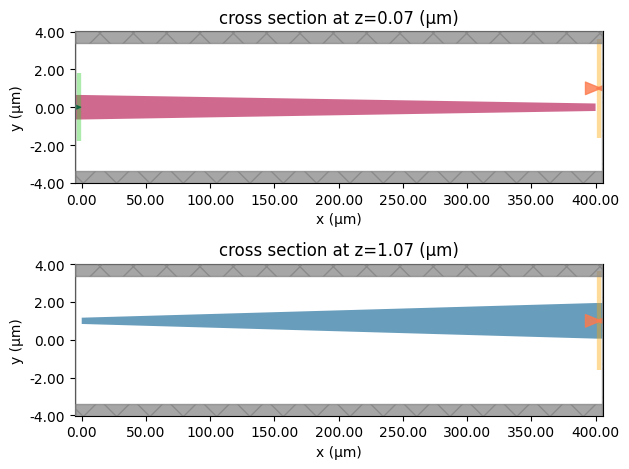

In [15]:
sim_box = td.Box.from_bounds(
    rmin=(-buffer_x, -w_AlOx_wg / 2 - buffer_y, -buffer_z),
    rmax=(
        l_taper_opt + buffer_x,
        w_AlOx_wg / 2 + buffer_y,
        t_SiN_top + t_SiN_bottom + t_SiN_gap + t_spacer + t_AlOx + buffer_z,
    ),
)

fdtd_sim = td.Simulation(
    center=sim_box.center,
    size=sim_box.size,
    run_time=4e-12,
    structures=create_structures(l_taper_opt, y_shift_opt),
    sources=[mode_source],
    monitors=[mode_monitor],
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=20, wavelength=lda0),
    medium=SiO2,
)

fig, ax = plt.subplots(2, 1, tight_layout=True)
fdtd_sim.plot(z=t_SiN_bottom, ax=ax[0])
ax[0].set_aspect("auto")
fdtd_sim.plot(z=t_SiN_top + t_SiN_bottom + t_SiN_gap + t_spacer + t_AlOx / 2, ax=ax[1])
ax[1].set_aspect("auto")
plt.show()

Run the FDTD simulation.

In [16]:
# Create a job for the given FDTD simulation
job = web.Job(simulation=fdtd_sim, task_name="test_name")

# Request an estimated compute cost for the created job
_ = web.estimate_cost(job.task_id)

↑ simulation.hdf5.gz ━━━━━━━━━━━━━━━━━━━━━━━━━ 100.0% • 2.1/2.1 kB • ? • 0:00:00

23:14:05 Eastern Standard Time Estimated FlexCredit cost: 9.106. Minimum cost   
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

23:14:06 Eastern Standard Time Estimated FlexCredit cost: 9.106. Minimum cost   
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

In [17]:
sim_data = job.run()

↓ simulation_data.hdf5.gz ━━━━━━━━━━━━━━━━━━━━ 100.0% • 4.1/4.1 kB • ? • 0:00:00

23:14:09 Eastern Standard Time Loading simulation from simulation_data.hdf5

Plot the coupling efficiency as a function of wavelength. The results confirm the design’s low loss.

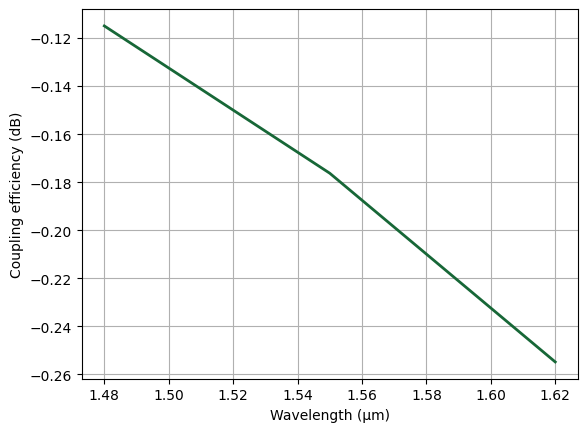

In [18]:
# Extract mode transmission amplitudes for the fundamental mode in the forward (+) direction
amp = sim_data["mode"].amps.sel(mode_index=0, direction="+").values

# Convert complex amplitudes to power transmission (|amp|^2)
T = np.abs(amp) ** 2

# Report coupling efficiency in dB
plt.plot(ldas, 10 * np.log10(T), linewidth=2)
plt.xlabel("Wavelength (μm)")
plt.ylabel("Coupling efficiency (dB)")
plt.grid()
plt.show()